# Loss / accuracy test: `no_comms` size-25, **all init scales** (all probes, smoothed)

Extension of [`nb_loss_curves_no_comms_size25_init0001_architecture_compare.ipynb`](nb_loss_curves_no_comms_size25_init0001_architecture_compare.ipynb):

- **Architectures:** `task_routed`, `shared`, `single_module` (capacity-matched `single_module_rnn_50_nb2*`).
- **`init_scale`:** `0.001`, `0.01`, `0.1`, `1.0` (default / no `_init` suffix), `2`.
- **Curves:** loss and accuracy using **all probes** (`probe_filter=None`), then **rolling mean/sem** with `smooth_window=25` (same as `*_summary_all_smoothed` in the reference notebook).
- **Plots:** 3×3 facets (architecture × same/near/far); **each panel overlays all init scales** with a **purple → yellow** colormap (smallest init = purple, largest = yellow).


In [1]:
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    from IPython.display import display
except ImportError:
    display = print

project_root = Path.cwd().resolve()
if project_root.name != 'a1b2_modular':
    if (project_root / 'a1b2_modular').exists():
        project_root = project_root / 'a1b2_modular'
    else:
        for parent in [project_root, *project_root.parents]:
            if parent.name == 'a1b2_modular':
                project_root = parent
                break
os.chdir(project_root)

from a1b2.utils.run_config import build_run_id

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

sim_root = project_root / 'data' / 'simulations'
config_path = project_root / 'a1b2' / 'models' / 'experiments.json'
settings = json.loads(config_path.read_text())

architecture_order = ['task_routed', 'shared', 'single_module']
condition_order = ['same', 'near', 'far']
phase_order = ['A1', 'B', 'A2']

INIT_SCALE_ORDER = [0.001, 0.01, 0.1, 1.0, 2.0]

_py_cmap = mcolors.LinearSegmentedColormap.from_list(
    'init_purple_yellow', ['#5c2d91', '#ffd740'], N=256
)
INIT_COLORS = {
    s: _py_cmap(i / max(1, len(INIT_SCALE_ORDER) - 1))
    for i, s in enumerate(INIT_SCALE_ORDER)
}


def condition_name_for(architecture_group: str, init_scale: float) -> str:
    if architecture_group == 'task_routed':
        base = 'two_module_rnn_25_task_routed_no_comms_nb2'
    elif architecture_group == 'shared':
        base = 'two_module_rnn_25_no_comms_nb2'
    elif architecture_group == 'single_module':
        base = 'single_module_rnn_50_nb2'
    else:
        raise ValueError(architecture_group)
    if float(init_scale) == 1.0:
        return base
    if float(init_scale) == int(init_scale):
        return f'{base}_init{int(init_scale)}'
    return f'{base}_init{init_scale}'


rows = []
for arch in architecture_order:
    for init_s in INIT_SCALE_ORDER:
        name = condition_name_for(arch, init_s)
        try:
            condition = next(c for c in settings['conditions'] if c['name'] == name)
        except StopIteration:
            rows.append({
                'condition_name': name,
                'architecture_group': arch,
                'init_scale': float(init_s),
                'run_id': None,
                'folder_path': '',
                'path_exists': False,
                'n_npz': 0,
                'config_ok': False,
            })
            continue
        run_id = build_run_id(condition)
        folder = sim_root / run_id
        rows.append({
            'condition_name': name,
            'architecture_group': arch,
            'init_scale': float(init_s),
            'run_id': run_id,
            'folder_path': str(folder),
            'path_exists': folder.exists(),
            'n_npz': len(list(folder.glob('sim_*.npz'))) if folder.exists() else 0,
            'config_ok': True,
        })

grid_df = pd.DataFrame(rows)
display(grid_df)
missing_cfg = grid_df[~grid_df['config_ok']]
if len(missing_cfg):
    print('Missing experiments.json entries:', len(missing_cfg))
    display(missing_cfg[['condition_name', 'architecture_group', 'init_scale']])
missing_runs = grid_df[grid_df['config_ok'] & ~grid_df['path_exists']]
if len(missing_runs):
    print('Configured but no simulation folder yet:', len(missing_runs))
    display(missing_runs[['condition_name', 'run_id']])


/home/kat/workspace/Structure-Function-Analysis-of-Network-Topologies/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,condition_name,architecture_group,init_scale,run_id,folder_path,path_exists,n_npz,config_ok
0,two_module_rnn_25_task_routed_no_comms_nb2_ini...,task_routed,0.001,two_module_rnn_25_task_routed_no_comms_nb2_ini...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True
1,two_module_rnn_25_task_routed_no_comms_nb2_ini...,task_routed,0.010,two_module_rnn_25_task_routed_no_comms_nb2_ini...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True
2,two_module_rnn_25_task_routed_no_comms_nb2_ini...,task_routed,0.100,two_module_rnn_25_task_routed_no_comms_nb2_ini...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True
3,two_module_rnn_25_task_routed_no_comms_nb2,task_routed,1.000,two_module_rnn_25_task_routed_no_comms_nb2_nb2...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True
4,two_module_rnn_25_task_routed_no_comms_nb2_init2,task_routed,2.000,two_module_rnn_25_task_routed_no_comms_nb2_ini...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True
5,two_module_rnn_25_no_comms_nb2_init0.001,shared,0.001,two_module_rnn_25_no_comms_nb2_init0.001_nb2_s...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True
6,two_module_rnn_25_no_comms_nb2_init0.01,shared,0.010,two_module_rnn_25_no_comms_nb2_init0.01_nb2_sh...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True
7,two_module_rnn_25_no_comms_nb2_init0.1,shared,0.100,two_module_rnn_25_no_comms_nb2_init0.1_nb2_sha...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True
8,two_module_rnn_25_no_comms_nb2,shared,1.000,two_module_rnn_25_no_comms_nb2_nb2_shared_sp0_...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True
9,two_module_rnn_25_no_comms_nb2_init2,shared,2.000,two_module_rnn_25_no_comms_nb2_init2_nb2_share...,/home/kat/workspace/Structure-Function-Analysi...,True,305,True


In [2]:
def load_raw_ann_folder(folder: Path, keys=None):
    keys = ['losses', 'accuracy', 'probes', 'test_stim'] if keys is None else list(keys)
    condition_data = {'same': [], 'near': [], 'far': []}
    if not folder.exists():
        return condition_data
    for npz_path in sorted(folder.glob('sim_*.npz')):
        file_name = npz_path.name
        condition = next((cond for cond in condition_data if cond in file_name), None)
        if condition is None:
            continue
        with np.load(npz_path, allow_pickle=True) as data:
            entry = {'participant': npz_path.stem.replace('sim_', '')}
            for key in keys:
                if key in data:
                    entry[key] = data[key]
        condition_data[condition].append(entry)
    return condition_data


def load_curve_df(grid: pd.DataFrame, value_key: str, probe_filter=None, max_phase_trial_index_exclusive=None):
    rows = []
    valid_grid = grid[grid['path_exists']].copy()
    for _, row in tqdm(valid_grid.iterrows(), total=len(valid_grid), desc=f'Loading {value_key} curves'):
        init_scale = float(row['init_scale'])
        ann_data = load_raw_ann_folder(Path(row['folder_path']), keys=[value_key, 'probes', 'test_stim'])
        for condition, entries in ann_data.items():
            for entry in entries:
                if value_key not in entry or 'probes' not in entry or 'test_stim' not in entry:
                    continue
                values = np.asarray(entry[value_key])
                probes = np.asarray(entry['probes'])
                test_stim = np.asarray(entry['test_stim'])
                if values.ndim != 2 or probes.ndim != 2 or test_stim.ndim != 2:
                    continue
                n_phases, n_trials = values.shape
                for phase_idx in range(min(3, n_phases)):
                    phase_name = phase_order[phase_idx]
                    phase_values = values[phase_idx].astype(float)
                    phase_probes = probes[phase_idx].astype(float)
                    phase_test = test_stim[phase_idx].astype(float)
                    valid = np.isfinite(phase_values) & np.isfinite(phase_probes) & np.isfinite(phase_test)
                    if probe_filter is not None:
                        valid = valid & (phase_probes == probe_filter)
                    valid_idx = np.where(valid)[0]
                    if max_phase_trial_index_exclusive is not None:
                        valid_idx = valid_idx[valid_idx < max_phase_trial_index_exclusive]
                    for local_order, trial_idx in enumerate(valid_idx):
                        rows.append({
                            'init_scale': init_scale,
                            'architecture_group': row['architecture_group'],
                            'run_id': row['run_id'],
                            'participant': entry['participant'],
                            'condition': condition,
                            'phase': phase_name,
                            'trial_idx_within_phase': int(local_order),
                            'global_trial_idx': int(phase_idx * n_trials + trial_idx),
                            'value': float(phase_values[trial_idx]),
                            'probe': int(phase_probes[trial_idx]),
                            'test_stim': int(phase_test[trial_idx]),
                        })
    return pd.DataFrame(rows)


def summarize_curves_with_init(curve_df: pd.DataFrame, smooth_window=None, value_label='value'):
    if curve_df is None or curve_df.empty:
        return pd.DataFrame()
    gcols = ['init_scale', 'architecture_group', 'condition', 'phase', 'global_trial_idx']
    summary = (
        curve_df.groupby(gcols, observed=True)
        .agg(mean_value=('value', 'mean'), sem_value=('value', 'sem'), n=('participant', 'nunique'))
        .reset_index()
        .sort_values(gcols)
    )
    mean_c = f'mean_{value_label}'
    sem_c = f'sem_{value_label}'
    summary = summary.rename(columns={'mean_value': mean_c, 'sem_value': sem_c})
    if smooth_window is not None and smooth_window > 1:
        smooth_keys = ['init_scale', 'architecture_group', 'condition', 'phase']
        summary[mean_c] = (
            summary.groupby(smooth_keys, observed=True)[mean_c]
            .transform(lambda s: s.rolling(smooth_window, min_periods=1, center=True).mean())
        )
        summary[sem_c] = (
            summary.groupby(smooth_keys, observed=True)[sem_c]
            .transform(lambda s: s.fillna(0).rolling(smooth_window, min_periods=1, center=True).mean())
        )
    return summary


SMOOTH_WINDOW = 25

loss_df_all = load_curve_df(grid_df, value_key='losses', probe_filter=None)
loss_summary_all_smoothed = summarize_curves_with_init(
    loss_df_all, smooth_window=SMOOTH_WINDOW, value_label='loss'
)

accuracy_df_all = load_curve_df(grid_df, value_key='accuracy', probe_filter=None)
accuracy_summary_all_smoothed = summarize_curves_with_init(
    accuracy_df_all, smooth_window=SMOOTH_WINDOW, value_label='accuracy'
)

print('loss_df_all', loss_df_all.shape)
print('loss_summary_all_smoothed', loss_summary_all_smoothed.shape)
print('accuracy_df_all', accuracy_df_all.shape)
print('accuracy_summary_all_smoothed', accuracy_summary_all_smoothed.shape)
display(loss_summary_all_smoothed.head())
display(accuracy_summary_all_smoothed.head())


Loading accuracy curves: 100%|██████████| 15/15 [11:41<00:00, 46.77s/it]


loss_df_all (164700000, 11)
loss_summary_all_smoothed (1620000, 8)
accuracy_df_all (164700000, 11)
accuracy_summary_all_smoothed (1620000, 8)


,init_scale,architecture_group,condition,phase,global_trial_idx,mean_loss,sem_loss,n
0,0.001,shared,far,A1,0,0.508039,0.001098,101
1,0.001,shared,far,A1,1,0.507314,0.001119,101
2,0.001,shared,far,A1,2,0.507008,0.001147,101
3,0.001,shared,far,A1,3,0.506611,0.001209,101
4,0.001,shared,far,A1,4,0.506312,0.001252,101


,init_scale,architecture_group,condition,phase,global_trial_idx,mean_accuracy,sem_accuracy,n
0,0.001,shared,far,A1,0,0.376070,0.025257,101
1,0.001,shared,far,A1,1,0.387641,0.025459,101
2,0.001,shared,far,A1,2,0.391072,0.025545,101
3,0.001,shared,far,A1,3,0.396682,0.025732,101
4,0.001,shared,far,A1,4,0.400871,0.025960,101


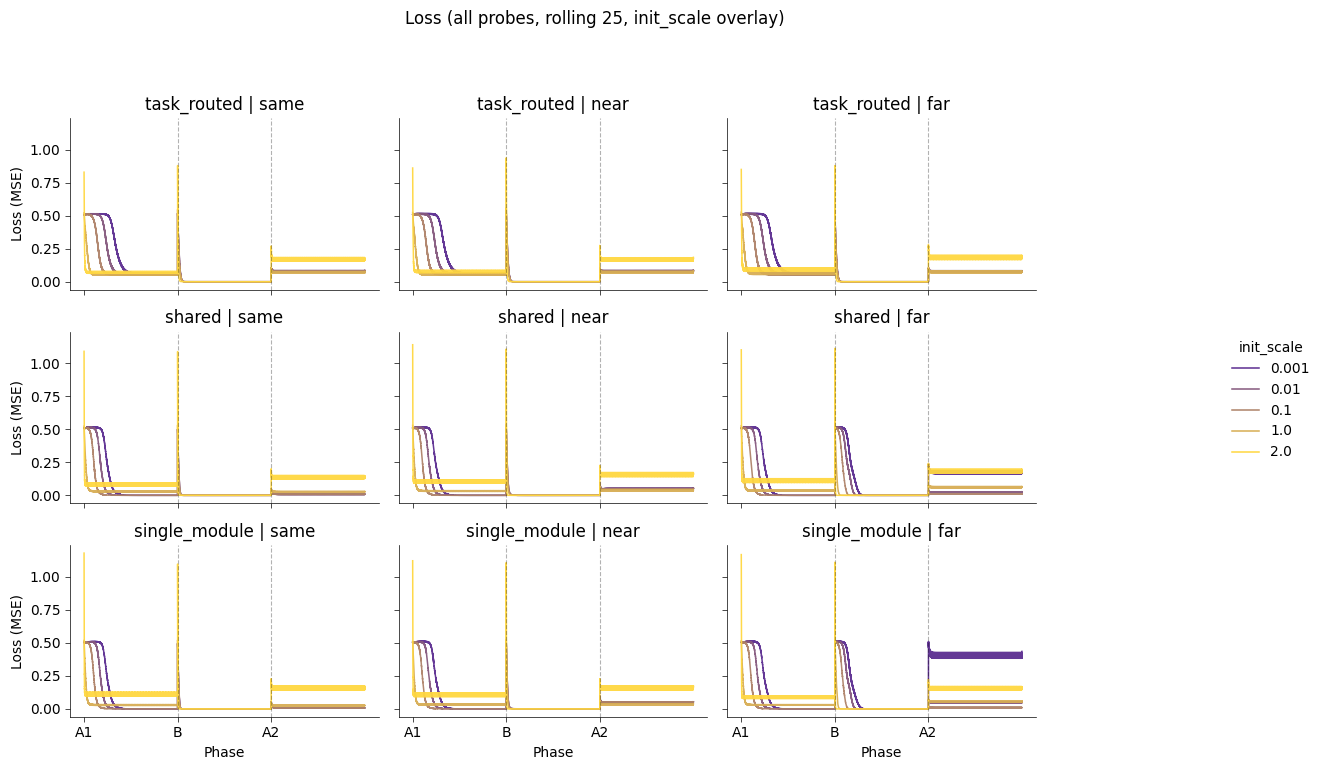

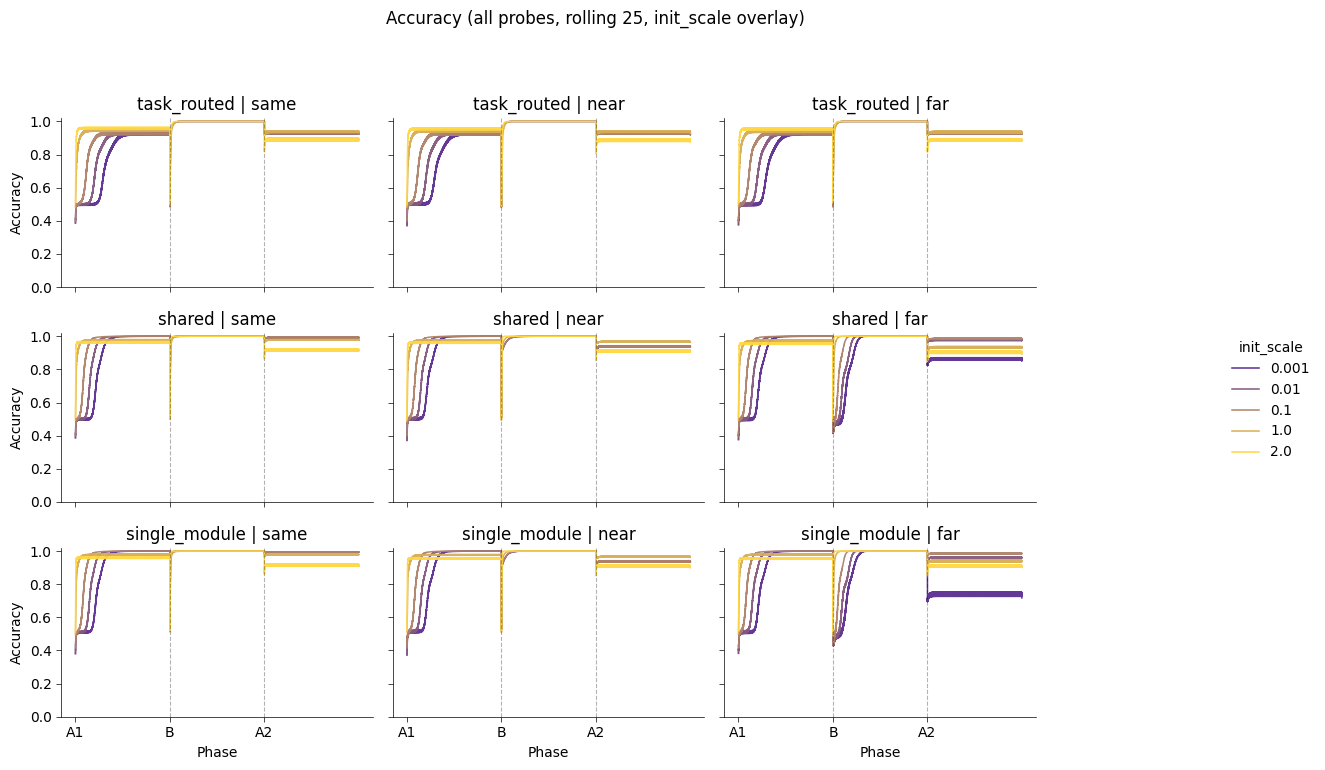

In [3]:
def _style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.tick_params(colors='black', width=0.5)
    ax.grid(False)


def plot_init_overlay_panels(
    summary_df: pd.DataFrame,
    title: str,
    *,
    mean_col: str,
    y_label: str,
    y_limits=None,
    linewidth: float = 1.1,
):
    """3×3: architecture × similarity; overlay one line per init_scale (purple → yellow)."""
    if summary_df is None or summary_df.empty:
        print(f'No rows for {title}.')
        return

    fig, axes = plt.subplots(len(architecture_order), len(condition_order), figsize=(12, 7.5), sharex=True, sharey=True)
    if len(architecture_order) == 1 and len(condition_order) == 1:
        axes = np.array([[axes]])
    elif len(architecture_order) == 1:
        axes = np.array([axes])
    elif len(condition_order) == 1:
        axes = np.array([[ax] for ax in axes])

    handles = []
    labels = []
    for init_s in INIT_SCALE_ORDER:
        h = plt.Line2D([0], [0], color=INIT_COLORS[init_s], linewidth=linewidth, label=str(init_s))
        handles.append(h)
        labels.append(str(init_s))

    for row_idx, arch in enumerate(architecture_order):
        for col_idx, condition in enumerate(condition_order):
            ax = axes[row_idx, col_idx]
            sub = summary_df[
                (summary_df['condition'] == condition) & (summary_df['architecture_group'] == arch)
            ].copy()
            if sub.empty:
                ax.set_title(f'{arch} | {condition}')
                _style_axes(ax)
                continue

            b_start = sub.loc[sub['phase'] == 'B', 'global_trial_idx'].min()
            a2_start = sub.loc[sub['phase'] == 'A2', 'global_trial_idx'].min()

            for init_s in INIT_SCALE_ORDER:
                sub_i = sub[np.isclose(sub['init_scale'].astype(float), float(init_s))]
                if sub_i.empty:
                    continue
                sub_i = sub_i.sort_values('global_trial_idx')
                x = sub_i['global_trial_idx'].to_numpy()
                y = sub_i[mean_col].to_numpy()
                ax.plot(x, y, color=INIT_COLORS[init_s], linewidth=linewidth, alpha=0.95)

            if pd.notna(b_start) and pd.notna(a2_start):
                ax.axvline(float(b_start), color='k', linestyle='--', alpha=0.3, linewidth=0.8)
                ax.axvline(float(a2_start), color='k', linestyle='--', alpha=0.3, linewidth=0.8)
                xticks = [0.0, float(b_start), float(a2_start)]
                ax.set_xticks(xticks)
                ax.set_xticklabels(['A1', 'B', 'A2'])

            if y_limits is not None:
                ax.set_ylim(*y_limits)
            ax.set_title(f'{arch} | {condition}')
            _style_axes(ax)

    for ax in axes[-1, :]:
        ax.set_xlabel('Phase')
    for ax in axes[:, 0]:
        ax.set_ylabel(y_label)

    fig.legend(handles, labels, title='init_scale', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.88, 0.97])
    plt.show()


plot_init_overlay_panels(
    loss_summary_all_smoothed,
    f'Loss (all probes, rolling {SMOOTH_WINDOW}, init_scale overlay)',
    mean_col='mean_loss',
    y_label='Loss (MSE)',
)

plot_init_overlay_panels(
    accuracy_summary_all_smoothed,
    f'Accuracy (all probes, rolling {SMOOTH_WINDOW}, init_scale overlay)',
    mean_col='mean_accuracy',
    y_label='Accuracy',
    y_limits=(0, 1.02),
)
